<a href="https://colab.research.google.com/github/thehimanivarshney/E-Commerce-Product-Return-Sustainability-Prediction/blob/main/E_Commerce_return.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [220]:
df = pd.read_csv('/content/returns_sustainability_dataset.csv')

In [221]:
df

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,Not Returned,No Return,0,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,Returned,Size Issue,11,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD04995,PROD0122,USER0058,2024-08-12,Clothing,1729.90,5,4.50,Next-Day,Debit Card,...,Not Returned,No Return,0,8260.272500,0,8260.272500,2.0,1.0,2.0,1.0
4996,ORD04996,PROD0387,USER1666,2024-08-25,Books,1254.75,4,32.73,Express,COD,...,Not Returned,No Return,0,3376.281300,0,3376.281300,1.5,0.8,1.5,0.8
4997,ORD04997,PROD0072,USER0298,2023-11-15,Clothing,1183.28,3,31.03,Standard,Debit Card,...,Not Returned,No Return,0,2448.324648,0,2448.324648,1.0,0.6,1.0,0.6
4998,ORD04998,PROD0362,USER0968,2024-01-03,Books,1761.47,4,11.30,Express,Wallet,...,Not Returned,No Return,0,6249.695560,0,6249.695560,1.5,0.8,1.5,0.8


In [222]:
df.shape

(5000, 23)

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   object 
 1   Product_ID        5000 non-null   object 
 2   User_ID           5000 non-null   object 
 3   Order_Date        5000 non-null   object 
 4   Product_Category  5000 non-null   object 
 5   Product_Price     5000 non-null   float64
 6   Order_Quantity    5000 non-null   int64  
 7   Discount_Applied  5000 non-null   float64
 8   Shipping_Method   5000 non-null   object 
 9   Payment_Method    5000 non-null   object 
 10  User_Age          5000 non-null   int64  
 11  User_Gender       5000 non-null   object 
 12  User_Location     5000 non-null   object 
 13  Return_Status     5000 non-null   object 
 14  Return_Reason     5000 non-null   object 
 15  Days_to_Return    5000 non-null   int64  
 16  Order_Value       5000 non-null   float64


In [224]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

No missing values found!


In [225]:
print("\n Statistical Summary (Numerical Features)")
print(df.describe().T)


 Statistical Summary (Numerical Features)
                   count         mean          std         min         25%  \
Product_Price     5000.0  1054.294740   548.560406  100.090000  580.937500   
Order_Quantity    5000.0     2.997600     1.400709    1.000000    2.000000   
Discount_Applied  5000.0    25.011476    14.430681    0.000000   12.827500   
User_Age          5000.0    41.551800    13.890195   18.000000   30.000000   
Days_to_Return    5000.0     9.204200    16.753156    0.000000    0.000000   
Order_Value       5000.0  2366.996469  1834.851991   52.165727  928.078449   
Return_Cost       5000.0    58.000000    90.761487    0.000000    0.000000   
Profit_Loss       5000.0  2308.996469  1838.461511 -147.834273  863.905130   
CO2_Emissions     5000.0     1.500100     0.410346    1.000000    1.000000   
Packaging_Waste   5000.0     0.599520     0.280142    0.200000    0.400000   
CO2_Saved         5000.0     1.066600     0.764448    0.000000    0.000000   
Waste_Avoided     500

## Exploratory Data Analysis(EDA)

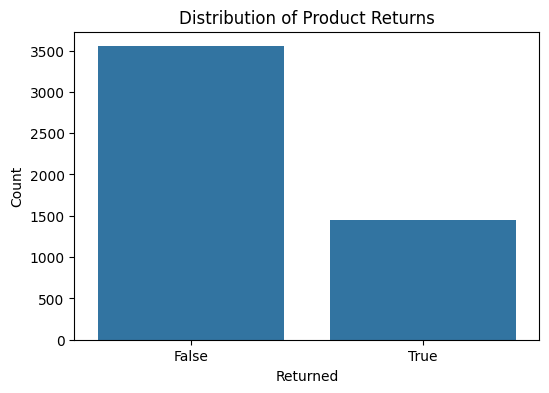

In [259]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_returned')
plt.title('Distribution of Product Returns')
plt.xlabel('Returned')
plt.ylabel('Count')
plt.show()

In [260]:
df.columns = df.columns.str.strip()

In [227]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

In [228]:
df["is_returned"] = df["Return_Status"].str.lower().eq("returned")

In [229]:
df['Return_Status'].value_counts()


,count
Return_Status,
Not Returned,3550
Returned,1450


In [230]:
overall_return_rate = df["is_returned"].mean()
print("\nOverall return rate:", round(overall_return_rate * 100, 2), "%")


Overall return rate: 29.0 %


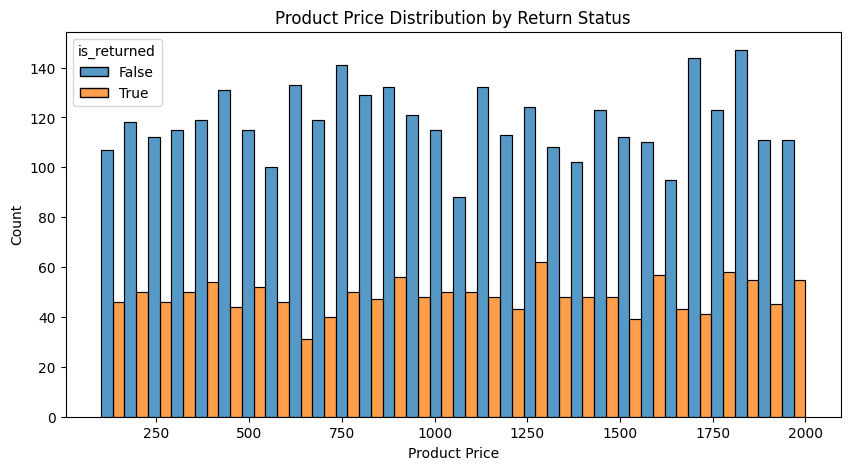

In [231]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Product_Price', hue='is_returned', multiple='dodge', bins=30)
plt.title('Product Price Distribution by Return Status')
plt.xlabel('Product Price')
plt.ylabel('Count')
plt.show()

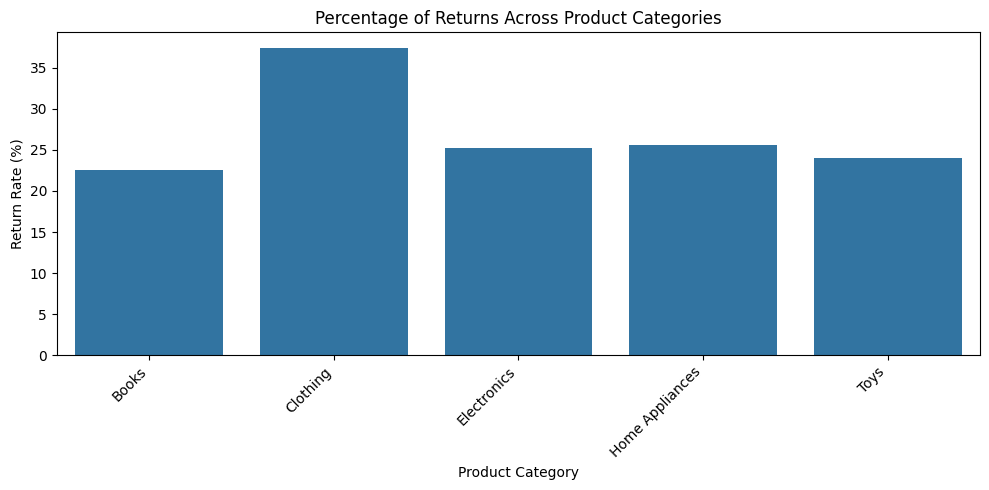

In [232]:
plt.figure(figsize=(10, 5))
category_return_rate = df.groupby('Product_Category')['is_returned'].mean().reset_index()
category_return_rate['is_returned'] *= 100 # Convert to percentage

sns.barplot(data=category_return_rate, x='Product_Category', y='is_returned')
plt.title('Percentage of Returns Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

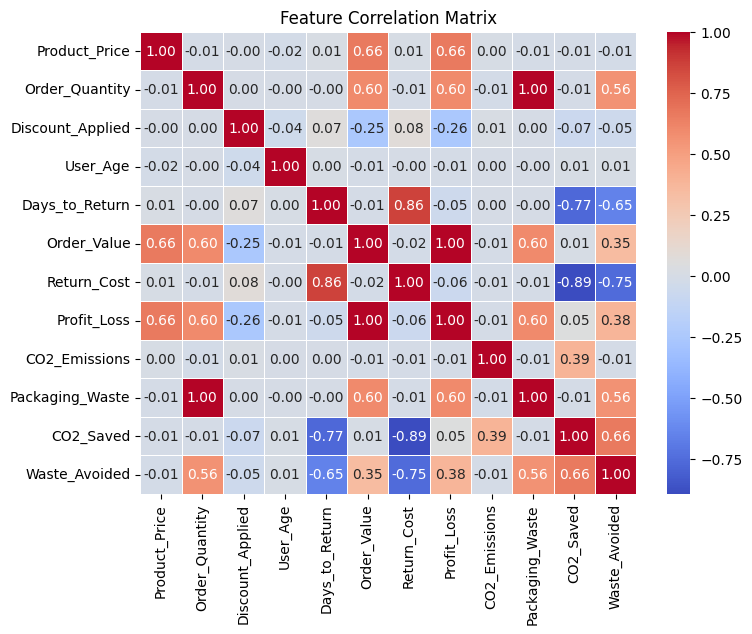

In [233]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## Visualizing Financial Metrics in Relation to Return Status

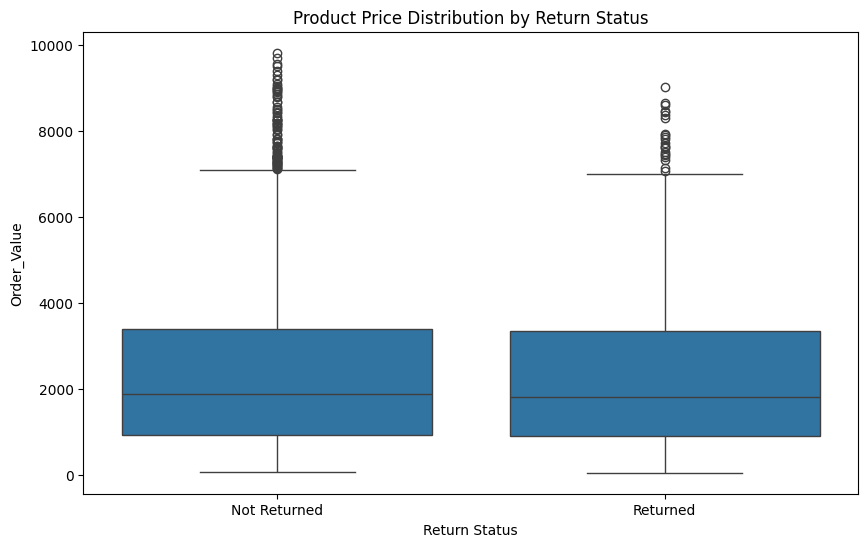

In [234]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Return_Status', y='Order_Value', data=df)
plt.title('Product Price Distribution by Return Status')
plt.xlabel('Return Status')
plt.ylabel('Order_Value')
plt.show()

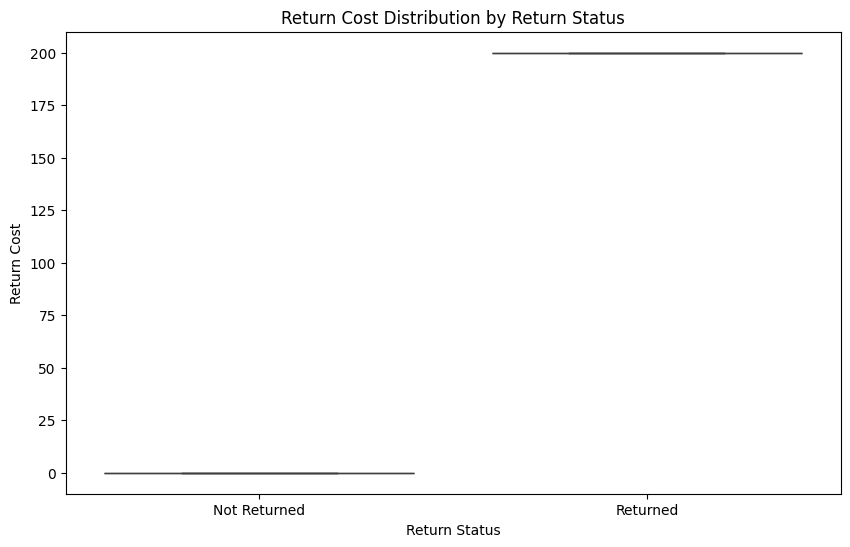

In [235]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Return_Status', y='Return_Cost', data=df)
plt.title('Return Cost Distribution by Return Status')
plt.xlabel('Return Status')
plt.ylabel('Return Cost')
plt.show()

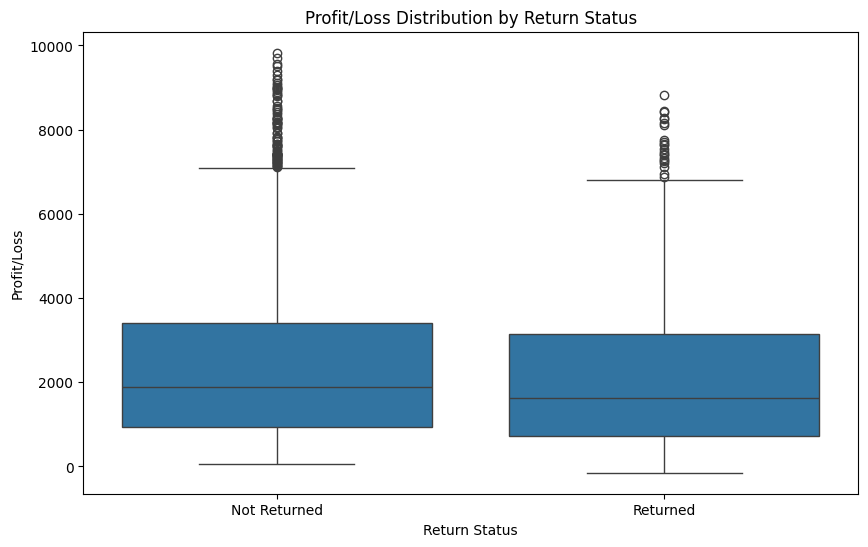

In [236]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Return_Status', y='Profit_Loss', data=df)
plt.title('Profit/Loss Distribution by Return Status')
plt.xlabel('Return Status')
plt.ylabel('Profit/Loss')
plt.show()

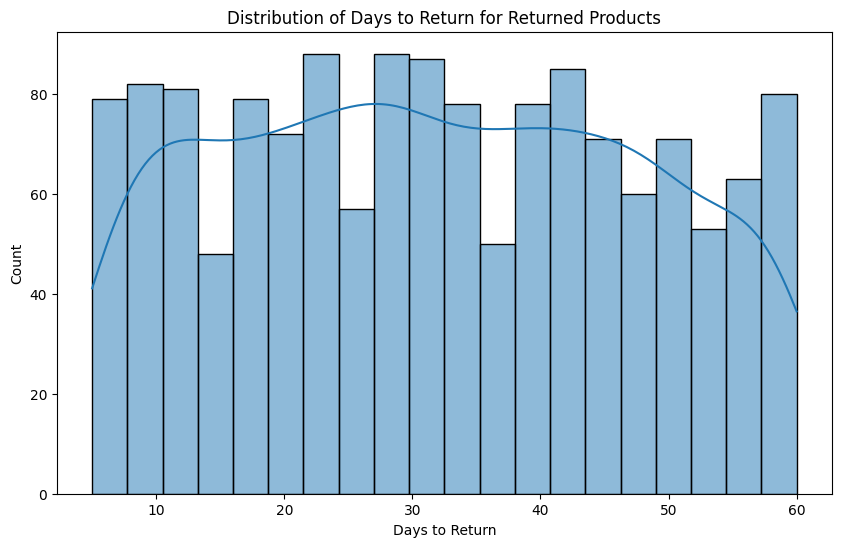

In [237]:
returned_df = df[df['Return_Status'] == 'Returned']
plt.figure(figsize=(10, 6))
sns.histplot(returned_df['Days_to_Return'], bins=20, kde=True)
plt.title('Distribution of Days to Return for Returned Products')
plt.xlabel('Days to Return')
plt.ylabel('Count')
plt.show()

## Data Preparation for Machine Learning Model

In [238]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])


In [239]:
df['Is_Returned'] = df['Return_Status'].apply(lambda x: 1 if x == 'Returned' else 0)


In [240]:
features = ['Product_Price', 'Order_Quantity', 'Discount_Applied', 'User_Age',
            'Shipping_Method', 'Payment_Method', 'Product_Category']


In [241]:
X = df[features]

In [242]:
y = df['Is_Returned']

In [243]:
X = pd.get_dummies(X, columns=['Shipping_Method', 'Payment_Method', 'Product_Category'], drop_first=True)

print("Features (X) after one-hot encoding:")
display(X.head())
print("Target variable (y):")
display(y.head())

Features (X) after one-hot encoding:


,Product_Price,Order_Quantity,Discount_Applied,User_Age,Shipping_Method_Next-Day,Shipping_Method_Standard,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Wallet,Product_Category_Clothing,Product_Category_Electronics,Product_Category_Home Appliances,Product_Category_Toys
0,1720.71,2,30.46,57,True,False,False,False,True,True,False,False,False
1,744.06,5,29.62,55,True,False,False,False,True,False,False,False,True
2,983.68,5,47.80,37,False,False,False,False,True,True,False,False,False
3,1855.65,2,2.90,47,False,False,False,False,False,False,False,False,False
4,1770.97,5,44.42,35,False,False,False,False,False,False,False,True,False


Target variable (y):


,Is_Returned
0,0
1,1
2,0
3,0
4,1


## Machine Learning Implementation

In [244]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Data split into training and testing sets successfully.")

X_train shape: (3500, 13)
X_test shape: (1500, 13)
y_train shape: (3500,)
y_test shape: (1500,)
Data split into training and testing sets successfully.




## Model: Random Forest Classifier

In [245]:
from sklearn.ensemble import RandomForestClassifier


In [246]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [247]:
rf_y_pred = rf_model.predict(X_test_scaled)

In [248]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_report = classification_report(y_test, rf_y_pred)
rf_cm = confusion_matrix(y_test, rf_y_pred)

In [249]:
print(f"Accuracy: {rf_accuracy:.4f}")
print(rf_report)
print(rf_cm)

Accuracy: 0.6900
              precision    recall  f1-score   support

           0       0.72      0.93      0.81      1066
           1       0.36      0.09      0.15       434

    accuracy                           0.69      1500
   macro avg       0.54      0.51      0.48      1500
weighted avg       0.61      0.69      0.62      1500

[[995  71]
 [394  40]]


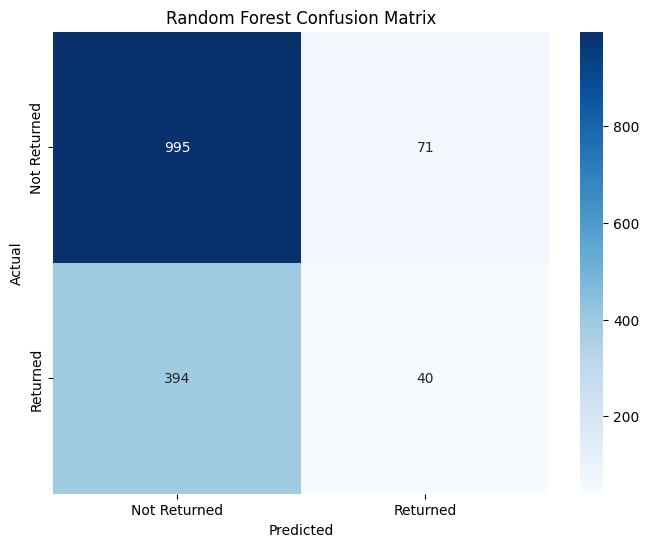

In [250]:
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Returned', 'Returned'], yticklabels=['Not Returned', 'Returned'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Hyperparameter Tuning

In [251]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


### Logistic Regression Hyperparameter Tuning

In [252]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced', max_iter=2000),
    param_grid_lr,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring='f1',
    n_jobs=-1
)

grid_search_lr.fit(X_train_scaled, y_train)

print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best F1 score for Logistic Regression: {grid_search_lr.best_score_:.4f}")

best_lr_model = grid_search_lr.best_estimator_
lr_y_pred_tuned = best_lr_model.predict(X_test_scaled)

lr_accuracy_tuned = accuracy_score(y_test, lr_y_pred_tuned)
lr_report_tuned = classification_report(y_test, lr_y_pred_tuned)
lr_cm_tuned = confusion_matrix(y_test, lr_y_pred_tuned)

print(f"Accuracy: {lr_accuracy_tuned:.4f}")
print(lr_report_tuned)
print(lr_cm_tuned)

Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 score for Logistic Regression: 0.4278
Accuracy: 0.6040
              precision    recall  f1-score   support

           0       0.76      0.64      0.70      1066
           1       0.37      0.51      0.43       434

    accuracy                           0.60      1500
   macro avg       0.57      0.58      0.56      1500
weighted avg       0.65      0.60      0.62      1500

[[684 382]
 [212 222]]


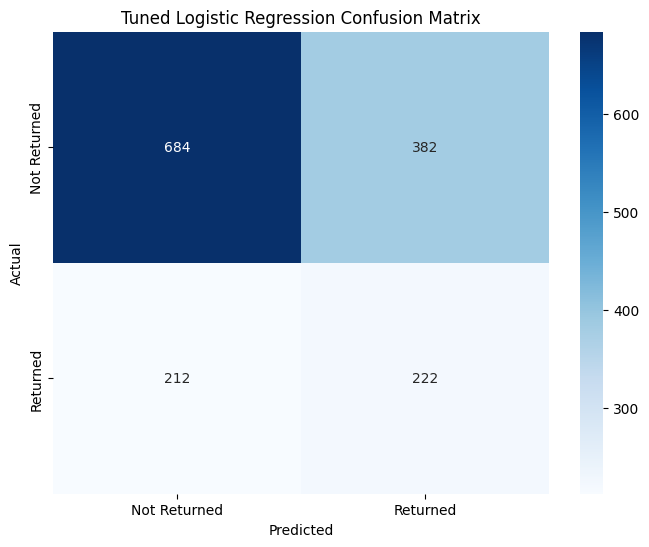

In [253]:
plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Returned', 'Returned'], yticklabels=['Not Returned', 'Returned'])
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### XGBoost Hyperparameter Tuning

In [254]:
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9]
}

grid_search_xgb = GridSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight_value, use_label_encoder=False),
    param_grid_xgb,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring='f1',
    n_jobs=-1
)

grid_search_xgb.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:15:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=5, random_state=42),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.9]},
             scoring='f1')

In [255]:
print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best F1 score for XGBoost: {grid_search_xgb.best_score_:.4f}")

Best parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best F1 score for XGBoost: 0.4276


In [256]:
best_xgb_model = grid_search_xgb.best_estimator_
xgb_y_pred_tuned = best_xgb_model.predict(X_test_scaled)

xgb_accuracy_tuned = accuracy_score(y_test, xgb_y_pred_tuned)
xgb_report_tuned = classification_report(y_test, xgb_y_pred_tuned)
xgb_cm_tuned = confusion_matrix(y_test, xgb_y_pred_tuned)

print(f"Accuracy: {xgb_accuracy_tuned:.4f}")
print(xgb_report_tuned)
print(xgb_cm_tuned)

Accuracy: 0.5940
              precision    recall  f1-score   support

           0       0.77      0.62      0.68      1066
           1       0.36      0.54      0.43       434

    accuracy                           0.59      1500
   macro avg       0.57      0.58      0.56      1500
weighted avg       0.65      0.59      0.61      1500

[[657 409]
 [200 234]]


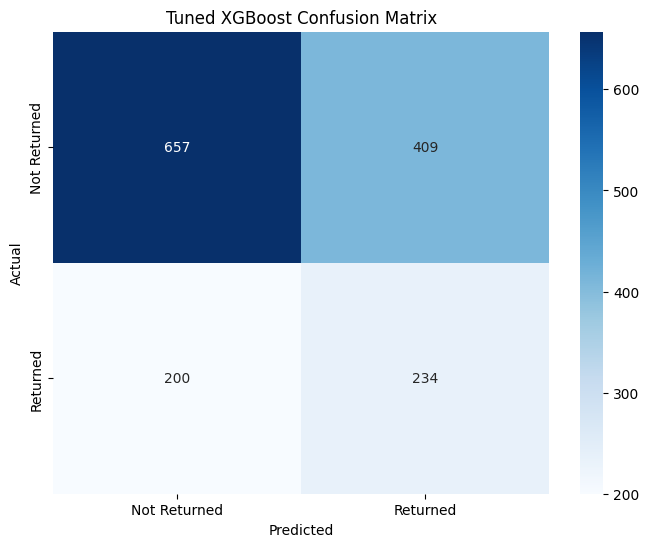

In [257]:
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Returned', 'Returned'], yticklabels=['Not Returned', 'Returned'])
plt.title('Tuned XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

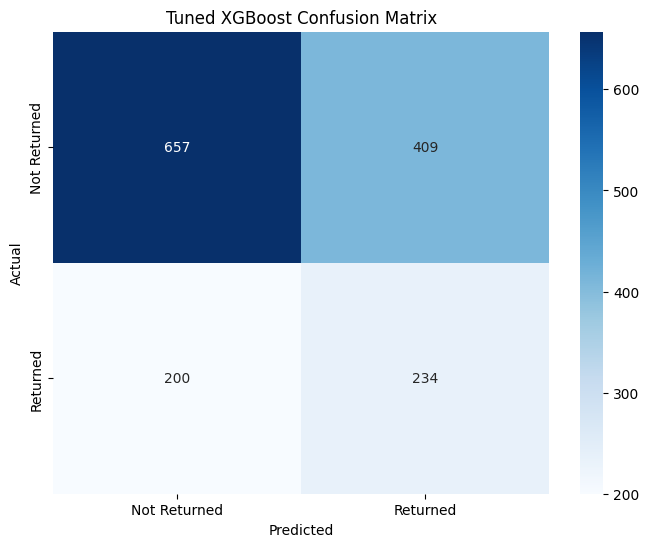

In [261]:
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Returned', 'Returned'], yticklabels=['Not Returned', 'Returned'])
plt.title('Tuned XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Scatterplots for Feature Relationships

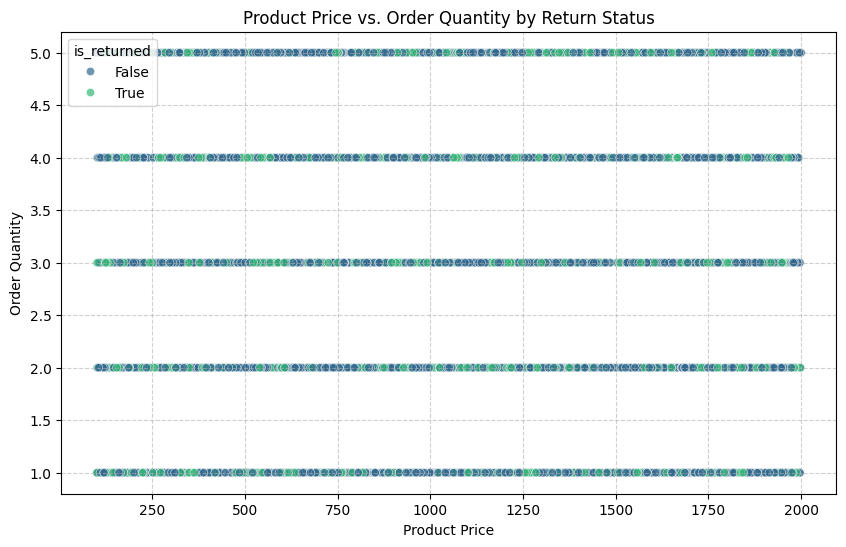

In [270]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Product_Price', y='Order_Quantity', hue='is_returned', palette='viridis', alpha=0.7)
plt.title('Product Price vs. Order Quantity by Return Status')
plt.xlabel('Product Price')
plt.ylabel('Order Quantity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

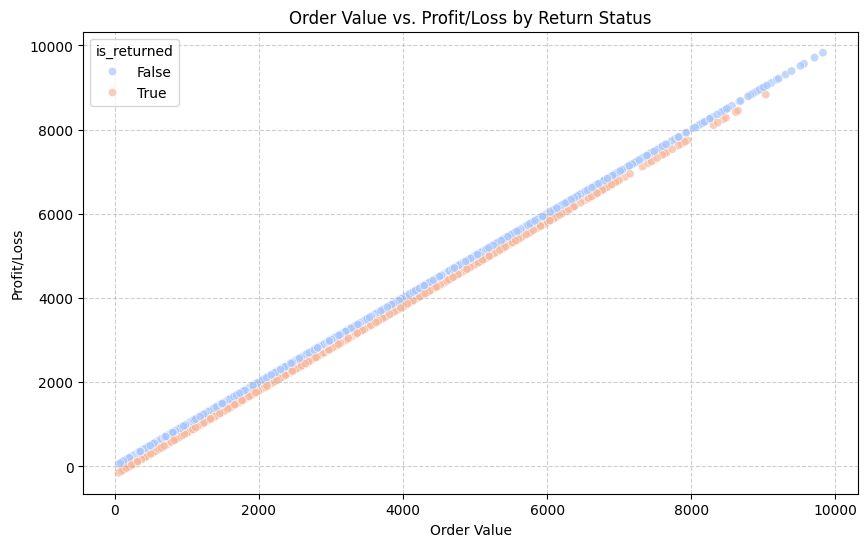

In [271]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Order_Value', y='Profit_Loss', hue='is_returned', palette='coolwarm', alpha=0.7)
plt.title('Order Value vs. Profit/Loss by Return Status')
plt.xlabel('Order Value')
plt.ylabel('Profit/Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

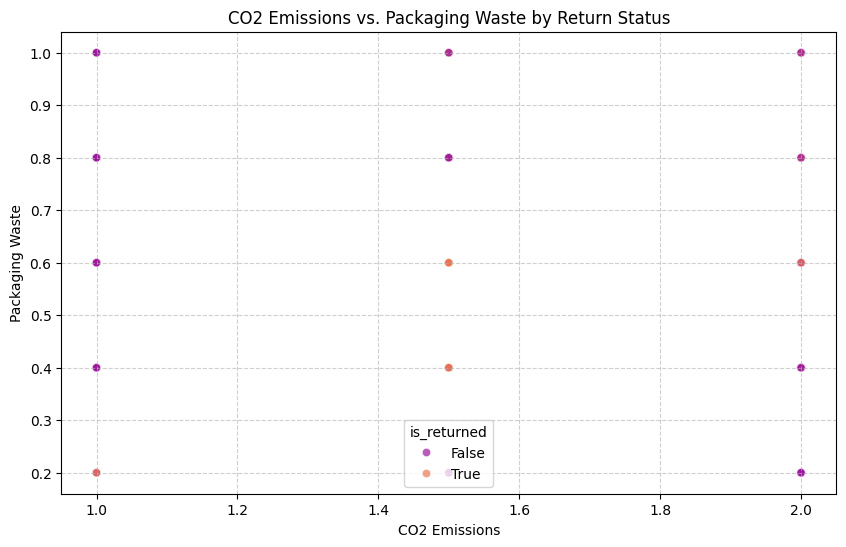

In [272]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CO2_Emissions', y='Packaging_Waste', hue='is_returned', palette='plasma', alpha=0.7)
plt.title('CO2 Emissions vs. Packaging Waste by Return Status')
plt.xlabel('CO2 Emissions')
plt.ylabel('Packaging Waste')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()